# **1. Perkenalan Dataset**


# Titanic Survival Prediction

Dataset yang digunakan adalah Titanic Dataset.

Tujuan:
Memprediksi apakah seorang penumpang selamat (Survived)
berdasarkan informasi demografis dan karakteristik perjalanan.

Sumber:
https://www.kaggle.com/c/titanic/data

Target:
Survived
- 0 = Tidak Selamat
- 1 = Selamat

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df = pd.read_csv('../titanic.csv')

print("Shape Dataset:")
print(df.shape)

df.head()

print("Dataset Information:")
df.info()

print("Dataset Description:")
print(df.describe())

Shape Dataset:
(891, 12)
Dataset Information:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Dataset Description:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.3

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Distribusi Target:
Survived
0    549
1    342
Name: count, dtype: int64


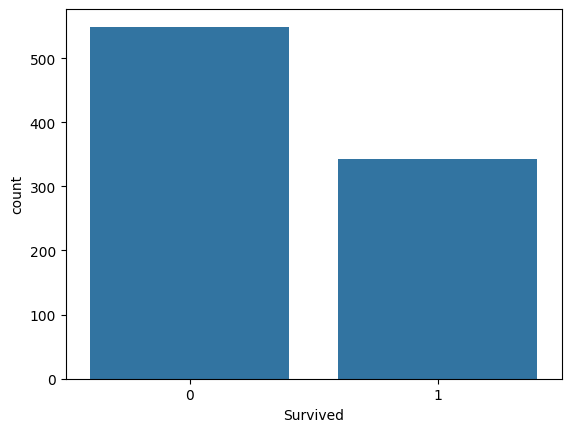

Distribusi Jenis Kelamin:
Sex
male      577
female    314
Name: count, dtype: int64


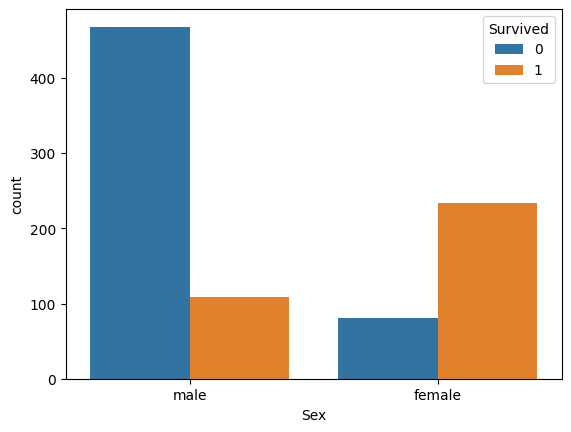

Distribusi Kelas Penumpang:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


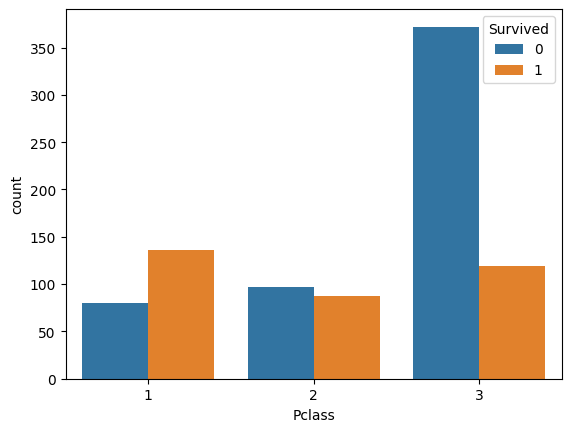

Distribusi Umur:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


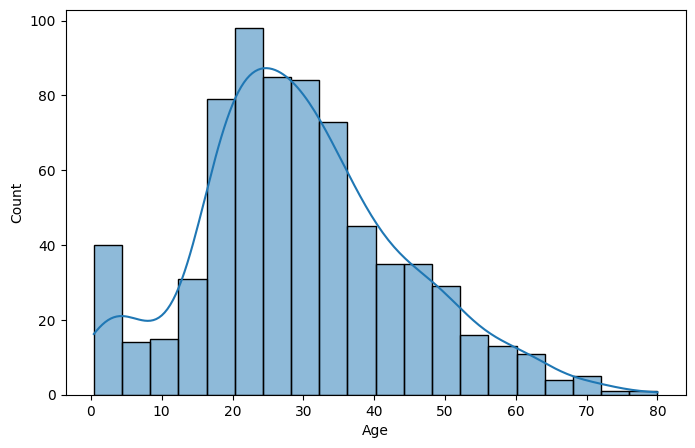

Korelasi Numerik:


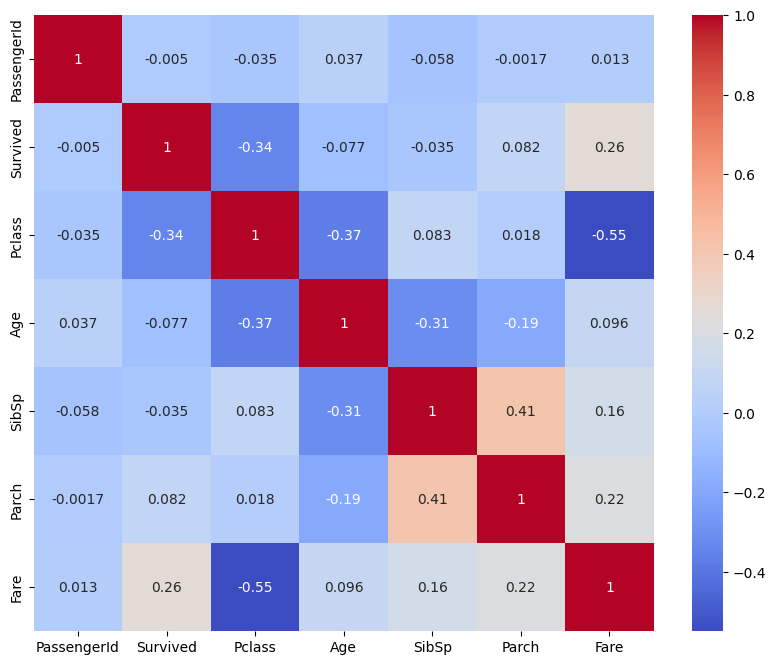

In [6]:
#Cek Missing Value
print(df.isnull().sum())

#Distribusi Target
print("Distribusi Target:")
print(df['Survived'].value_counts())
sns.countplot(
    data=df,
    x='Survived'
)

plt.show()

#Distribusi Jenis Kelamin
print("Distribusi Jenis Kelamin:")
print(df['Sex'].value_counts())
sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.show()

#Distribusi Kelas Penumpang
print("Distribusi Kelas Penumpang:")
print(df['Pclass'].value_counts())
sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.show()

#Distribusi Umur
print("Distribusi Umur:")
print(df['Age'].describe())
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True
)

plt.show()

#Korelasi Numerik
print("Korelasi Numerik:")
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()



Insight EDA:

1. Terdapat missing value pada Age, Cabin, dan Embarked.
2. Penumpang perempuan memiliki tingkat survival lebih tinggi.
3. Penumpang kelas 1 memiliki peluang hidup lebih tinggi.
4. Age memiliki beberapa missing value yang perlu ditangani.
5. Cabin memiliki missing value sangat banyak sehingga akan dihapus.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
#copy dataset untuk preprocessing
data = df.copy()

#drop kolom yang tidak diperlukan
data = data.drop(
    columns=[
        'PassengerId',
        'Name',
        'Ticket',
        'Cabin'
    ]
)

#Missing Value
#Age
data['Age'] = data['Age'].fillna(
    data['Age'].median()
)

#Embarked
data['Embarked'] = data['Embarked'].fillna(
    data['Embarked'].mode()[0]
)

#Cek Missing Value
print("Cek Missing Value Setelah Imputasi:")
print(data.isnull().sum())

#Encoding
le = LabelEncoder()

data['Sex'] = le.fit_transform(
    data['Sex']
)

data['Embarked'] = le.fit_transform(
    data['Embarked']
)

#cek hasil
print("Dataset Setelah Preprocessing:")
print(data.head())

#Simpan Dataset Hasil Preprocessing
data.to_csv('../titanic_preprocessed.csv', index=False)

#verifikasi
print(data.shape)
data.info()


Cek Missing Value Setelah Imputasi:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Dataset Setelah Preprocessing:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2
(891, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  